In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [3]:
words = open('names.txt','r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [4]:
len(words)

32033

In [11]:
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.']=0
itos = {i:s for s,i in stoi.items()}
vocab_size=len(itos)
print(itos)
print(vocab_size)


{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}
27


In [14]:
#build dataset 
block_size=3
def build_dataset(words):
    X,Y = [],[]
    for w in words:
        context = [0]*block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix]
    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape,Y.shape)
    return X,Y
import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr,Ytr = build_dataset(words[:n1])
Xdev,Ydev = build_dataset(words[n1:n2])
Xte,Yte = build_dataset(words[n2:])


            

torch.Size([182437, 3]) torch.Size([182437])
torch.Size([22781, 3]) torch.Size([22781])
torch.Size([22928, 3]) torch.Size([22928])


In [63]:
n_embd = 10
n_hidden = 200
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((vocab_size,n_embd))
W1 = torch.randn((n_embd*block_size,n_hidden), generator = g) * ((5/3)/((n_embd * block_size) ** 0.5)) #0.2
#B1 = torch.randn((n_hidden), generator = g) * 0.01
W2 = torch.randn((n_hidden,vocab_size),  generator=g) * 0.01
B2 = torch.randn((vocab_size), generator = g) * 0

bngains = torch.ones((1,n_hidden))
bnbias = torch.zeros((1,n_hidden))

bnmean_running = torch.zeros((1,n_hidden))
bnstd_running = torch.ones((1,n_hidden))

parameters = [W1,W2,B2,C,bnbias,bngains]
print(sum(p.nelement() for p in parameters))
for p in parameters:
    p.requires_grad = True

12097


In [64]:
max_steps = 200000
batch_size = 32
lossi = []
for i in range(max_steps):
    # minibatch
    ix = torch.randint(0, Xtr.shape[0],(batch_size,),generator = g)
    Xb , Yb = Xtr[ix],Ytr[ix]

    #forward pass
    embd = C[Xb] # embed charactres into vectors
    embcat = embd.view(embd.shape[0],-1) # concatenate vectors getting converted to certain shape
    hpreact = embcat @ W1 #+ B1 # first layer
    bnmeani = hpreact.mean(0,keepdim=True)
    bnstdi = hpreact.std(0,keepdim=True)
    hpreact = bngains*(hpreact -bnmeani )/(bnstdi)+bnbias

    with torch.no_grad():
        bnmean_running  = 0.999*bnmean_running + 0.001*bnmeani
        bnstd_running = 0.999*bnstd_running + 0.001*bnstdi
    
    h = torch.tanh(hpreact) # hidden layre
    logits = h @ W2 + B2 # output layer
    loss = F.cross_entropy(logits,Yb) # loss

    #backward pass 
    for p in parameters:
        p.grad = None # zero grad
    loss.backward() # backward prop

    #update
    lr = 0.1 if i<100000 else 0.01 # learn decay (IMP)
    for p in parameters:
        p.data += - lr * p.grad

    # track status
    if i % 10000 ==0:
        print(f'{i:7d}/{max_steps:7d} : {loss.item():.4f}')
    
    lossi.append(loss.log10().item())
    
    

SyntaxError: invalid syntax (2943204438.py, line 12)

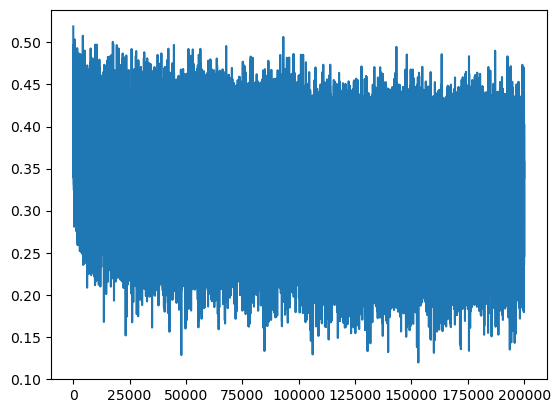

In [56]:
plt.plot(lossi)

In [57]:
with torch.no_grad():
    emb = C [Xtr]
    embcat = emb.view(emb.shape[0],-1)
    hpreact = embcat @ W1 +B1

    bnmean  = hpreact.mean(0,keepdim=True)
    bnstd = hpreact.std(0,keepdim=True)
    

In [60]:
bnstd

tensor([[1.9858, 2.2031, 2.1144, 2.2481, 2.7017, 2.7721, 1.8513, 2.1442, 2.3871,
         2.0620, 2.4215, 1.5723, 2.2455, 2.3589, 1.9834, 1.7254, 2.1905, 1.9278,
         2.3857, 2.2900, 1.9412, 2.2182, 2.2703, 1.9783, 2.1922, 2.3897, 2.1269,
         2.2522, 2.5306, 3.0293, 2.0224, 2.2165, 2.3004, 1.9588, 2.2160, 2.0209,
         1.8675, 2.3380, 2.0129, 1.8191, 2.4129, 2.1249, 2.1983, 2.2169, 2.1138,
         2.3324, 2.3149, 2.2229, 2.0494, 2.4469, 2.7254, 2.1071, 2.0993, 2.1431,
         2.3621, 2.4181, 2.0931, 1.8689, 2.1702, 2.2732, 2.3689, 2.1814, 2.2773,
         2.4444, 1.9729, 2.3137, 2.0383, 2.5602, 2.2990, 2.1314, 2.0614, 2.1796,
         2.1952, 2.0553, 2.5374, 2.0556, 2.2645, 2.0789, 2.1924, 2.1171, 2.1932,
         1.9269, 2.7104, 2.4477, 2.7238, 1.8984, 2.3842, 2.4894, 2.5393, 2.2486,
         2.4262, 2.9409, 2.0526, 2.0225, 2.0558, 2.0548, 2.0532, 1.7420, 2.6339,
         2.2387, 1.8921, 2.9464, 2.0809, 2.3396, 1.8176, 2.1374, 2.3057, 2.4382,
         2.1324, 2.3626, 2.0

In [61]:
bnstd_running 

tensor([[1.9649, 2.1808, 2.0853, 2.2245, 2.6503, 2.7534, 1.8241, 2.1204, 2.3625,
         2.0563, 2.4031, 1.5618, 2.2427, 2.3291, 1.9588, 1.7011, 2.1656, 1.9017,
         2.3528, 2.2723, 1.9103, 2.1933, 2.2486, 1.9631, 2.1708, 2.3643, 2.1052,
         2.2318, 2.5007, 3.0267, 2.0115, 2.1956, 2.2739, 1.9433, 2.1805, 1.9960,
         1.8529, 2.3179, 2.0056, 1.8029, 2.3982, 2.1110, 2.1808, 2.1977, 2.0943,
         2.3157, 2.2891, 2.2155, 2.0213, 2.4140, 2.7078, 2.0912, 2.0770, 2.1180,
         2.3464, 2.4081, 2.0756, 1.8550, 2.1470, 2.2550, 2.3501, 2.1492, 2.2597,
         2.4480, 1.9501, 2.2871, 2.0200, 2.5348, 2.2733, 2.1076, 2.0478, 2.1634,
         2.1716, 2.0396, 2.5121, 2.0359, 2.2393, 2.0590, 2.1690, 2.0942, 2.1565,
         1.9031, 2.6784, 2.4233, 2.7014, 1.8778, 2.3485, 2.4634, 2.5043, 2.2268,
         2.3970, 2.9167, 2.0395, 2.0020, 2.0386, 2.0460, 2.0384, 1.7183, 2.6189,
         2.2194, 1.8788, 2.9357, 2.0540, 2.3193, 1.7959, 2.1236, 2.2701, 2.4126,
         2.1118, 2.3510, 1.9

In [62]:
@torch.no_grad()
def split_loss(split):
    x,y = {
        'train':{Xtr,Ytr},
        'dev':{Xdev,Ydev},
        'test':{Xte,Yte}
    }[split]
    emb = C [x]
    embcat = emb.view(emb.shape[0],-1)
    hpreact = embcat @ W1 + B1
    hpreact = bngains*(hpreact - bnmean_running)/bnstd_running+bnbias
    h = torch.tanh(hpreact)
    logits = h @ W2 + B2
    loss = F.cross_entropy(logits,y)
    print(split,loss.item())
split_loss("train")
split_loss('dev')

train 2.0635247230529785
dev 2.1238718032836914


In [24]:
# sampling
g = torch.Generator().manual_seed(2147483647)

for _ in range(20):
    out = []
    context = [0]*block_size
    while True:
        # forward pass the neural nets
        emb = C [torch.tensor(context)]
        h = torch.tanh(emb.view(1,-1) @ W1 + B1)
        logits = h @ W2 + B2
        prob = F.softmax(logits,dim=1)
        # sample from the distribution
        ix = torch.multinomial(prob,num_samples=  1,generator = g ).item()
        #shift the context window and track the samples
        context = context[1:] + [ix]
        out.append(ix)
        if ix ==0 :
            break
    print(''.join(itos[i] for i in out))
        
        

cerberleah.
mikion.
kayderrinishana.
nylandr.
kata.
kreyichukwton.
milian.
milie.
cavo.
keyten.
gen.
emmarsede.
eniavnyn.
zyonstihinitlactarlys.
kaspi.
dan.
glaryan.
isan.
jarienne.
azar.
